In [2]:
from transformers import  pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
parlbert = "chkla/parlbert-topic-german"
pipeline_classification_parlbert = pipeline("text-classification", model="chkla/parlbert-topic-german", top_k=None)

Device set to use cpu


In [4]:
df_results = pd.read_csv('parlbert_test.csv')
df_results_context = pd.read_csv('parlbert_test_context.csv')
df_results_context_1 = pd.read_csv('parlbert_test_context_1.csv')

df_results['parlbert_probs'] = df_results['parlbert_probs'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else None
)

df_results_context['parlbert_probs'] = df_results_context['parlbert_probs'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else None
)

df_results_context_1['parlbert_probs'] = df_results_context_1['parlbert_probs'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else None
)

In [5]:
# Function to get second-highest label & score
def second_best(preds):
    # Sort by score descending
    sorted_preds = sorted(preds, key=lambda x: x["score"], reverse=True)
    if len(sorted_preds) < 2:
        return None, None
    return sorted_preds[1]["label"], sorted_preds[1]["score"]

df_results['parlbert_second_label'] = df_results['parlbert_probs'].apply(
    lambda x: second_best(x)[0] if x else None
)
df_results['parlbert_second_score'] = df_results['parlbert_probs'].apply(
    lambda x: second_best(x)[1] if x else None
)

df_results_context['parlbert_second_label'] = df_results_context['parlbert_probs'].apply(
    lambda x: second_best(x)[0] if x else None
)
df_results_context['parlbert_second_score'] = df_results_context['parlbert_probs'].apply(
    lambda x: second_best(x)[1] if x else None
)

df_results_context_1['parlbert_second_label'] = df_results_context_1['parlbert_probs'].apply(
    lambda x: second_best(x)[0] if x else None
)
df_results_context_1['parlbert_second_score'] = df_results_context_1['parlbert_probs'].apply(
    lambda x: second_best(x)[1] if x else None
)

In [6]:
# Function to get second-highest label & score
def second_best(preds):
    # Sort by score descending
    sorted_preds = sorted(preds, key=lambda x: x["score"], reverse=True)
    if len(sorted_preds) < 2:
        return None, None
    return sorted_preds[1]["label"], sorted_preds[1]["score"]

df_results['parlbert_second_label'] = df_results['parlbert_probs'].apply(
    lambda x: second_best(x)[0] if x else None
)
df_results['parlbert_second_score'] = df_results['parlbert_probs'].apply(
    lambda x: second_best(x)[1] if x else None
)

## Evaluate dev set

In [7]:
# parlbert no context

In [8]:
df_dev = df_results.loc[df_results['split'] == 'dev']
df_dev_true = df_dev["label_name"]
df_dev_preds = df_dev["parlbert_label"]

In [9]:
print("Validation set")

# Classification report (precision, recall, f1)
print(classification_report(df_dev_true, df_dev_preds))

f1_micro = f1_score(df_dev_true, df_dev_preds, average="micro")
f1_macro = f1_score(df_dev_true, df_dev_preds, average="macro")
f1_weighted = f1_score(df_dev_true, df_dev_preds, average="weighted")

print("F1 micro:", f1_micro)
print("F1 macro:", f1_macro)
print("F1 weighted:", f1_weighted)

Validation set
                precision    recall  f1-score   support

   Agriculture       0.75      0.76      0.75        50
         Civil       0.45      0.68      0.54       206
       Culture       0.30      0.47      0.37        15
       Defense       0.80      0.51      0.62       231
      Domestic       0.28      0.50      0.36       140
     Education       0.86      0.54      0.67       116
        Energy       0.95      0.69      0.80       117
   Environment       0.75      0.54      0.63        96
       Foreign       0.70      0.36      0.48       140
    Government       0.29      0.64      0.40       325
        Health       0.76      0.47      0.58       143
       Housing       0.86      0.60      0.71        60
   Immigration       0.44      0.42      0.43        73
 International       0.78      0.64      0.70      1220
         Labor       0.75      0.57      0.64       314
           Law       0.52      0.41      0.46       107
Macroeconomics       0.62      0

In [10]:
# Parlbert full context (2 previous sentences)

In [11]:
df_dev_context = df_results_context.loc[df_results_context['split'] == 'dev']
df_dev_preds_context = df_dev_context["parlbert_label"]

In [12]:
print("Validation set (context n=2)")

# Classification report (precision, recall, f1)
print(classification_report(df_dev_true, df_dev_preds_context))

f1_micro = f1_score(df_dev_true, df_dev_preds_context, average="micro")
f1_macro = f1_score(df_dev_true, df_dev_preds_context, average="macro")
f1_weighted = f1_score(df_dev_true, df_dev_preds_context, average="weighted")

print("F1 micro:", f1_micro)
print("F1 macro:", f1_macro)
print("F1 weighted:", f1_weighted)

Validation set (context n=2)
                precision    recall  f1-score   support

   Agriculture       0.62      0.80      0.70        50
         Civil       0.48      0.57      0.52       206
       Culture       0.28      0.53      0.36        15
       Defense       0.71      0.61      0.66       231
      Domestic       0.25      0.41      0.31       140
     Education       0.68      0.49      0.57       116
        Energy       0.76      0.67      0.71       117
   Environment       0.71      0.53      0.61        96
       Foreign       0.39      0.29      0.33       140
    Government       0.41      0.50      0.45       325
        Health       0.68      0.57      0.62       143
       Housing       0.66      0.67      0.66        60
   Immigration       0.38      0.37      0.37        73
 International       0.74      0.68      0.71      1220
         Labor       0.65      0.60      0.62       314
           Law       0.55      0.38      0.45       107
Macroeconomics    

In [13]:
# Parlbert full context (1 previous sentence)

In [14]:
df_dev_context_1 = df_results_context_1.loc[df_results_context['split'] == 'dev']
df_dev_preds_context_1 = df_dev_context_1["parlbert_label"]

In [15]:
print("Validation set (context=1)")

# Classification report (precision, recall, f1)
print(classification_report(df_dev_true, df_dev_preds_context_1))

f1_micro = f1_score(df_dev_true, df_dev_preds_context_1, average="micro")
f1_macro = f1_score(df_dev_true, df_dev_preds_context_1, average="macro")
f1_weighted = f1_score(df_dev_true, df_dev_preds_context_1, average="weighted")

print("F1 micro:", f1_micro)
print("F1 macro:", f1_macro)
print("F1 weighted:", f1_weighted)

Validation set (context=1)
                precision    recall  f1-score   support

   Agriculture       0.68      0.86      0.76        50
         Civil       0.49      0.66      0.56       206
       Culture       0.24      0.47      0.32        15
       Defense       0.76      0.59      0.67       231
      Domestic       0.29      0.50      0.36       140
     Education       0.67      0.46      0.54       116
        Energy       0.84      0.71      0.77       117
   Environment       0.72      0.54      0.62        96
       Foreign       0.52      0.35      0.42       140
    Government       0.41      0.58      0.48       325
        Health       0.69      0.50      0.58       143
       Housing       0.75      0.63      0.68        60
   Immigration       0.39      0.42      0.41        73
 International       0.75      0.67      0.71      1220
         Labor       0.68      0.61      0.64       314
           Law       0.53      0.38      0.45       107
Macroeconomics      

--> still works best without context

## Investigate "unlabelled"

In [16]:
df_unlabeled = df_results.loc[df_results['split'] == 'unlabeled']

In [17]:
df_unlabeled

,sentence,mapped_label,label_name,split,parlbert_label,parlbert_score,parlbert_probs,parlbert_second_label,parlbert_second_score


IndexError: index 0 is out of bounds for axis 0 with size 0

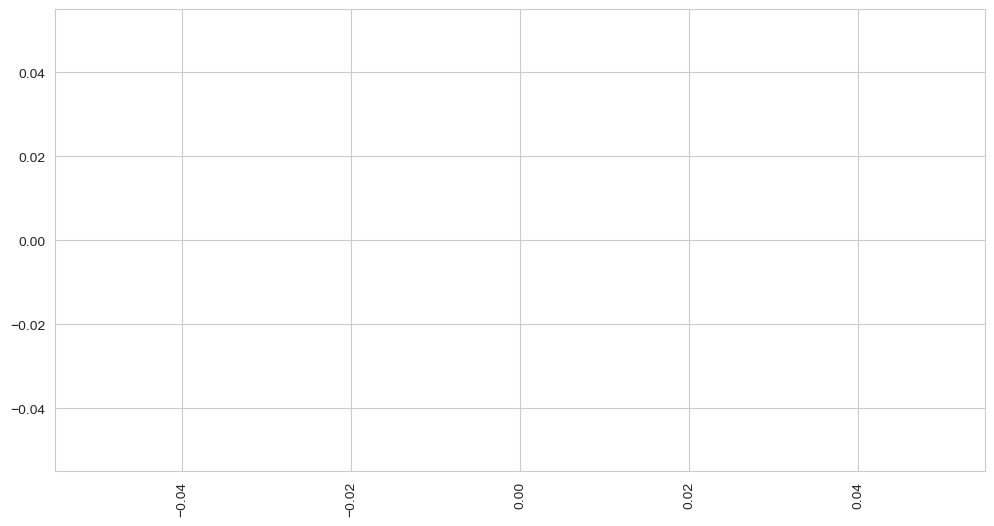

In [18]:
df_unlabeled['parlbert_label'].value_counts().sort_index().plot(kind='bar', figsize=(12,6))
plt.xlabel("Label ID")
plt.ylabel("Count")
plt.title("Distribution of 'unlabeled' Labels")
plt.show()

## Investigate probs

In [83]:
print(f"Vanilla mean labeled (dev): {df_dev.loc[:, 'parlbert_score'].mean()}")
print(f"Vanilla median labeled (dev): {df_dev.loc[:, 'parlbert_score'].median()}")

Vanilla mean labeled (dev): 0.8820062736089538
Vanilla median labeled (dev): 0.9832347631454468


In [84]:
df_dev_correct = df_dev.loc[df_dev['parlbert_label'] == df_dev['label_name']]
print(f"Vanilla correct mean labeled: {df_dev_correct.loc[:, 'parlbert_score'].mean()}")
print(f"Vanilla correct median labeled: {df_dev_correct.loc[:, 'parlbert_score'].median()}")
df_dev_incorrect = df_dev.loc[df_dev['parlbert_label'] != df_dev['label_name']]
print(f"Vanilla incorrect mean labeled: {df_dev_incorrect.loc[:, 'parlbert_score'].mean()}")
print(f"Vanilla incorrect median labeled: {df_dev_incorrect.loc[:, 'parlbert_score'].median()}")

Vanilla correct mean labeled: 0.9345079748132911
Vanilla correct median labeled: 0.9949778020381927
Vanilla incorrect mean labeled: 0.8040105298186777
Vanilla incorrect median labeled: 0.8894820213317871


In [85]:
df_dev_second_correct = df_dev.loc[df_dev['parlbert_second_label'] == df_dev['label_name']]
print(f"Vanilla second label correct mean: {df_dev_second_correct.loc[:, 'parlbert_second_score'].mean()}")
print(f"Vanilla second label correct median: {df_dev_second_correct.loc[:, 'parlbert_second_score'].median()}")
df_dev_second_incorrect = df_dev.loc[df_dev['parlbert_second_label'] != df_dev['label_name']]
print(f"Vanilla second label incorrect mean: {df_dev_second_incorrect.loc[:, 'parlbert_second_score'].mean()}")
print(f"Vanilla second label incorrect median: {df_dev_second_incorrect.loc[:, 'parlbert_second_score'].median()}")

Vanilla second label correct mean: 0.11349691683974499
Vanilla second label correct median: 0.053977156057953835
Vanilla second label incorrect mean: 0.05940326861693869
Vanilla second label incorrect median: 0.005333059001713991


In [86]:
# group by the true label
grouped = df_dev.groupby('label_name')

for label, group in grouped:
    correct_mask = group['parlbert_label'] == group['label_name']
    incorrect_mask = ~correct_mask

    correct_scores = group.loc[correct_mask, 'parlbert_score']
    incorrect_scores = group.loc[incorrect_mask, 'parlbert_score']

    print(f"Class: {label}")
    print(f"  Correct mean: {correct_scores.mean():.4f}")
    print(f"  Correct median: {correct_scores.median():.4f}")
    print(f"  Incorrect mean: {incorrect_scores.mean():.4f}")
    print(f"  Incorrect median: {incorrect_scores.median():.4f}")
    print("-" * 40)


Class: Agriculture
  Correct mean: 0.9765
  Correct median: 0.9947
  Incorrect mean: 0.7937
  Incorrect median: 0.8992
----------------------------------------
Class: Civil
  Correct mean: 0.9073
  Correct median: 0.9941
  Incorrect mean: 0.7709
  Incorrect median: 0.8855
----------------------------------------
Class: Culture
  Correct mean: 0.9682
  Correct median: 0.9932
  Incorrect mean: 0.8516
  Incorrect median: 0.9714
----------------------------------------
Class: Defense
  Correct mean: 0.9624
  Correct median: 0.9979
  Incorrect mean: 0.8195
  Incorrect median: 0.9500
----------------------------------------
Class: Domestic
  Correct mean: 0.9600
  Correct median: 0.9984
  Incorrect mean: 0.8487
  Incorrect median: 0.9499
----------------------------------------
Class: Education
  Correct mean: 0.9096
  Correct median: 0.9912
  Incorrect mean: 0.8172
  Incorrect median: 0.8845
----------------------------------------
Class: Energy
  Correct mean: 0.9881
  Correct median: 0.99

In [87]:
# Crosstab: true label vs predicted label
confusion_top = pd.crosstab(
    df_dev['label_name'], 
    df_dev['parlbert_label'], 
    rownames=['True Label'], 
    colnames=['Predicted Label'], 
    normalize='index'
)

# Sort by most confused classes
print(confusion_top)


Predicted Label  Agriculture     Civil   Culture   Defense  Domestic  \
True Label                                                             
Agriculture         0.760000  0.000000  0.000000  0.000000  0.080000   
Civil               0.000000  0.684466  0.004854  0.000000  0.009709   
Culture             0.000000  0.266667  0.466667  0.000000  0.000000   
Defense             0.000000  0.047619  0.000000  0.506494  0.017316   
Domestic            0.021429  0.014286  0.007143  0.000000  0.500000   
Education           0.000000  0.034483  0.000000  0.000000  0.025862   
Energy              0.000000  0.000000  0.000000  0.000000  0.034188   
Environment         0.031250  0.000000  0.000000  0.010417  0.104167   
Foreign             0.000000  0.000000  0.000000  0.000000  0.264286   
Government          0.003077  0.092308  0.006154  0.006154  0.006154   
Health              0.006993  0.076923  0.000000  0.000000  0.055944   
Housing             0.000000  0.000000  0.033333  0.000000  0.00

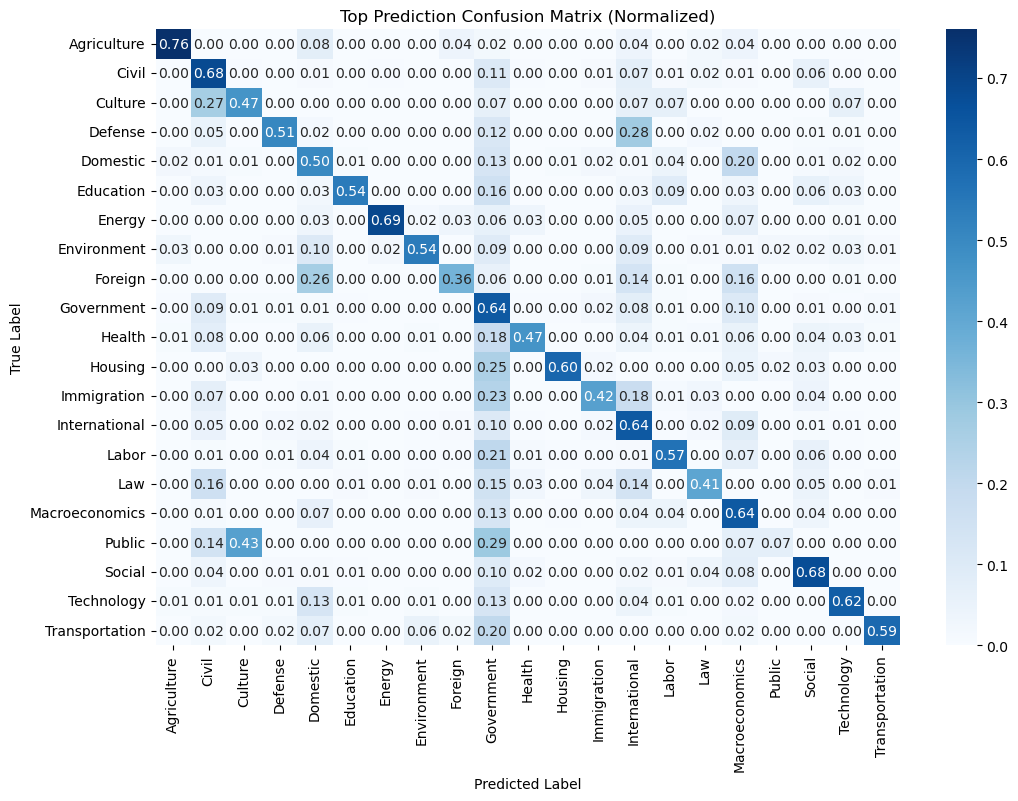

In [88]:
plt.figure(figsize=(12,8))
sns.heatmap(confusion_top, annot=True, fmt=".2f", cmap="Blues")
plt.title("Top Prediction Confusion Matrix (Normalized)")
plt.show()

most confused: government over-predicted, public(true)-culture(predicted) (0.5), defense(true)-international(predicted) (0.29), 

In [89]:
# Crosstab: true label vs predicted label
confusion_top = pd.crosstab(
    df_dev['label_name'], 
    df_dev['parlbert_second_label'], 
    rownames=['True Label'], 
    colnames=['Predicted Label'], 
    normalize='index'  # optional: fractions instead of counts
)

# Sort by most confused classes
print(confusion_top)


Predicted Label  Agriculture     Civil   Culture   Defense  Domestic  \
True Label                                                             
Agriculture         0.100000  0.020000  0.000000  0.000000  0.020000   
Civil               0.000000  0.116505  0.009709  0.004854  0.009709   
Culture             0.000000  0.133333  0.200000  0.000000  0.066667   
Defense             0.000000  0.246753  0.008658  0.103896  0.012987   
Domestic            0.014286  0.000000  0.014286  0.000000  0.178571   
Education           0.000000  0.051724  0.129310  0.000000  0.043103   
Energy              0.034188  0.008547  0.000000  0.008547  0.042735   
Environment         0.041667  0.000000  0.000000  0.000000  0.250000   
Foreign             0.071429  0.014286  0.042857  0.007143  0.178571   
Government          0.003077  0.113846  0.012308  0.000000  0.120000   
Health              0.111888  0.062937  0.000000  0.000000  0.104895   
Housing             0.000000  0.066667  0.033333  0.000000  0.10

In [1]:
plt.figure(figsize=(12,8))
sns.heatmap(confusion_top, annot=True, fmt=".2f", cmap="Blues")
plt.title("Top Prediction Confusion Matrix Second Label (Normalized)")
plt.show()

NameError: name 'plt' is not defined

## Evaluation on test set

In [92]:
df_test = df_results.loc[df_results['split'] == 'test']
df_test_true = df_test["label_name"]
df_test_preds = df_test["parlbert_label"]

In [93]:
print("Test set")
f1_micro = f1_score(df_test_true, df_test_preds, average="micro")
f1_macro = f1_score(df_test_true, df_test_preds, average="macro")
f1_weighted = f1_score(df_test_true, df_test_preds, average="weighted")

print("F1 macro:", f1_macro)
print("F1 micro:", f1_micro)
print("F1 weighted:", f1_weighted)
# Classification report (precision, recall, f1)
print(classification_report(df_test_true, df_test_preds))

Test set
F1 macro: 0.56138959413745
F1 micro: 0.6046112337503066
F1 weighted: 0.6219955935930435
                precision    recall  f1-score   support

   Agriculture       0.43      1.00      0.60         3
         Civil       0.48      0.65      0.55       136
       Culture       0.89      0.73      0.80        11
       Defense       0.80      0.43      0.56       119
      Domestic       0.45      0.60      0.52       247
     Education       0.83      0.56      0.67        72
        Energy       0.94      0.63      0.75       210
   Environment       0.62      0.54      0.58       100
       Foreign       0.79      0.32      0.45       170
    Government       0.24      0.74      0.36       235
        Health       0.55      0.70      0.62        37
       Housing       0.65      0.62      0.64        24
   Immigration       0.44      0.51      0.47        51
 International       0.75      0.63      0.68      1158
         Labor       0.74      0.52      0.61       321
      

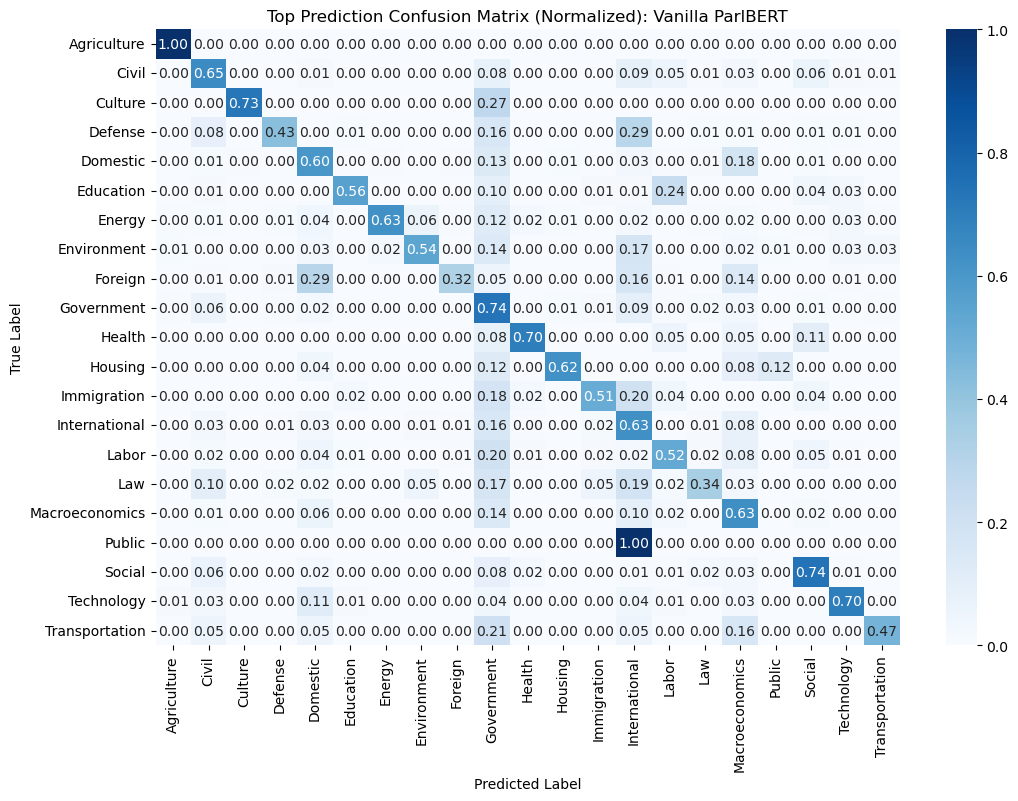

In [96]:
confusion_top = pd.crosstab(
    df_test['label_name'], 
    df_test['parlbert_label'], 
    rownames=['True Label'], 
    colnames=['Predicted Label'], 
    normalize='index')

plt.figure(figsize=(12,8))
sns.heatmap(confusion_top, annot=True, fmt=".2f", cmap="Blues")
plt.title("Top Prediction Confusion Matrix (Normalized): Vanilla ParlBERT")
plt.savefig('vanilla_parlbert_matrix.png',bbox_inches="tight") 
plt.show()